In [3]:
import os
import pandas as pd
import numpy as np
path = os.path.join( "..", "data", "processed", "accidents_preprocessed.csv")
df = pd.read_csv(path)

In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

# === 1. Split data
X = df.drop(columns=['grav'])  
y = df['grav']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f'eq_{str(c)}' for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f'eq_{str(c)}' for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns='equipements'), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns='equipements'), equip_test], axis=1)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder

# Colonnes
equip_cols = list(equip_train.columns)
cols_to_exclude = ['com'] + equip_cols
cols_to_ohe = [col for col in X_train.columns if col in X_train.select_dtypes(include='object') and col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe),
    ('target_enc', TargetEncoder(), ['com'])
], remainder='passthrough')

In [6]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline  # Pour compatibilité SMOTETomek
from imblearn.combine import SMOTETomek

pipeline = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('resampling', SMOTETomek(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.65      0.77      0.70     65070
           2       0.69      0.44      0.53     61671
           3       0.44      0.27      0.34     23801
           4       0.08      0.50      0.14      4110

    accuracy                           0.55    154652
   macro avg       0.47      0.49      0.43    154652
weighted avg       0.62      0.55      0.56    154652



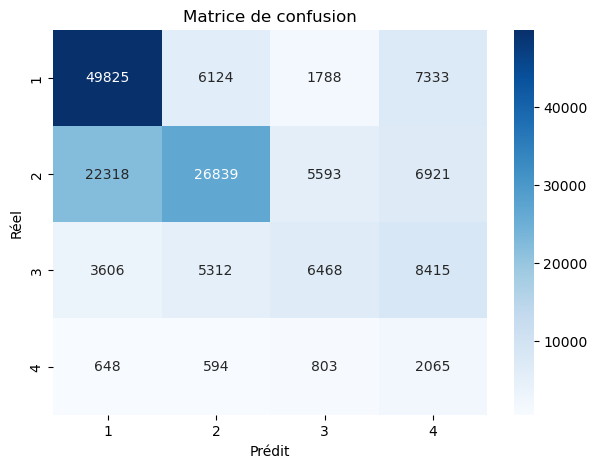

In [17]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report
import time

# --- Préparer les modèles
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# --- Dictionnaire des pipelines
pipelines = {
    "Random Forest": {
        "model": rf,
        "adjust_target": False  # pas de décalage
    },
    "XGBoost": {
        "model": xgb,
        "adjust_target": True  # décaler y de -1
    }
}



🏁 Modèle : Random Forest
⏱️ Temps d'entraînement : 261.29 sec
              precision    recall  f1-score   support

           1       0.73      0.75      0.74     65070
           2       0.64      0.57      0.60     61671
           3       0.42      0.47      0.44     23801
           4       0.14      0.19      0.16      4110

    accuracy                           0.62    154652
   macro avg       0.48      0.49      0.49    154652
weighted avg       0.63      0.62      0.62    154652



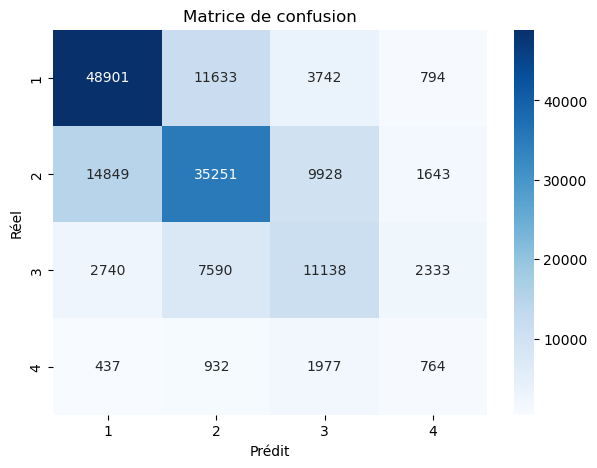


🏁 Modèle : XGBoost


/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:40:08] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


⏱️ Temps d'entraînement : 248.53 sec
              precision    recall  f1-score   support

           1       0.73      0.81      0.77     65070
           2       0.69      0.56      0.62     61671
           3       0.45      0.51      0.48     23801
           4       0.17      0.23      0.19      4110

    accuracy                           0.65    154652
   macro avg       0.51      0.53      0.52    154652
weighted avg       0.66      0.65      0.65    154652



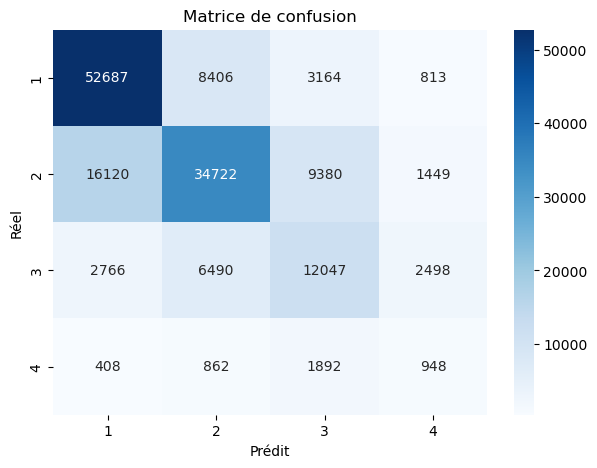

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


for name, config in pipelines.items():
    print(f"\n🏁 Modèle : {name}")
    
    # Décaler y si nécessaire
    y_train_fit = y_train - 1 if config["adjust_target"] else y_train
    y_test_fit = y_test - 1 if config["adjust_target"] else y_test

    # Pipeline complète
    pipe = ImbPipeline([
        ('encoding', preprocessor),
        ('resampling', SMOTETomek(random_state=42)),
        ('model', config["model"])
    ])

    # Entraînement
    start = time.time()
    pipe.fit(X_train, y_train_fit)
    end = time.time()

    # Prédictions
    y_pred = pipe.predict(X_test)

    # Redécaler les prédictions si nécessaire
    if config["adjust_target"]:
        y_pred = y_pred + 1

    # Évaluation
    print(f"⏱️ Temps d'entraînement : {end - start:.2f} sec")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    classes = sorted(y.unique())  
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion")
    plt.show()



/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:47:17] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


⏱️ Temps d'entraînement : 1.17 sec
              precision    recall  f1-score   support

           1       0.74      0.75      0.75     65070
           2       0.68      0.49      0.57     61671
           3       0.39      0.42      0.40     23801
           4       0.12      0.56      0.19      4110

    accuracy                           0.59    154652
   macro avg       0.48      0.55      0.48    154652
weighted avg       0.65      0.59      0.61    154652



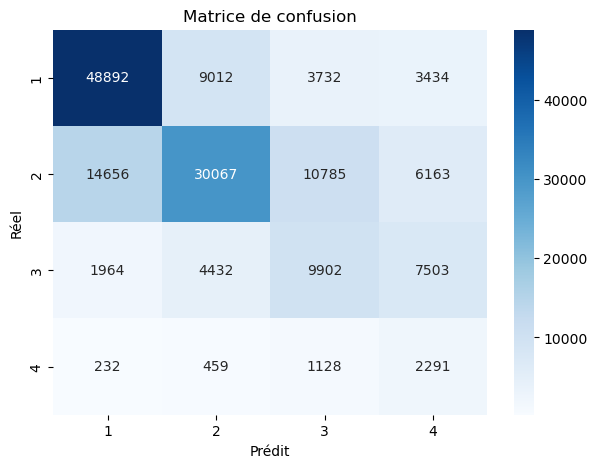

In [11]:
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report
import time

# Créer la pipeline
xgb = XGBClassifier(
    n_estimators=200,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

pipeline_xgb_under = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('model', xgb)
])

# Décaler les labels pour XGBoost (1-4 → 0-3)
y_train_adj = y_train - 1
y_test_adj = y_test - 1

start = time.time()
pipeline_xgb_under.fit(X_train, y_train_adj)
end = time.time()

y_pred = pipeline_xgb_under.predict(X_test)
y_pred = y_pred + 1  # Recaler 0-3 → 1-4

print(f"⏱️ Temps d'entraînement : {end - start:.2f} sec")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

In [12]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report
import numpy as np
import time

# 1. Créer le modèle
xgb = XGBClassifier(
    n_estimators=200,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# 2. Pipeline avec SMOTETomek et prétraitement
pipeline_xgb = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('resampling', SMOTETomek(random_state=42)),
    ('model', xgb)
])

# 3. Ajustement des labels pour XGBoost (1–4 → 0–3)
y_train_adj = y_train - 1
y_test_adj = y_test - 1

# 4. Entraînement
start = time.time()
pipeline_xgb.fit(X_train, y_train_adj)
end = time.time()

print(f"✅ Modèle entraîné en {end - start:.2f} sec")

# 5. Prédictions probabilistes
y_proba = pipeline_xgb.predict_proba(X_test)

# 6. Boucle sur plusieurs seuils pour la classe 4
print("\n🔁 Résultats pour différents seuils de la classe 4 (prédite si proba > seuil):")

for seuil in np.arange(0.20, 0.51, 0.05):
    y_pred_adj = []
    for prob in y_proba:
        if prob[3] > seuil:
            y_pred_adj.append(4)  # classe 4 = index 3
        else:
            # choisir la meilleure des classes 1–3 (index 0 à 2)
            pred = np.argmax(prob[:3]) + 1
            y_pred_adj.append(pred)

    print(f"\n📏 Seuil = {seuil:.2f}")
    print(classification_report(y_test, y_pred_adj, zero_division=0))

/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:02:04] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Modèle entraîné en 250.52 sec

🔁 Résultats pour différents seuils de la classe 4 (prédite si proba > seuil):

📏 Seuil = 0.20
              precision    recall  f1-score   support

           1       0.73      0.81      0.77     65070
           2       0.69      0.55      0.61     61671
           3       0.44      0.33      0.38     23801
           4       0.12      0.48      0.20      4110

    accuracy                           0.62    154652
   macro avg       0.50      0.54      0.49    154652
weighted avg       0.66      0.62      0.63    154652


📏 Seuil = 0.25
              precision    recall  f1-score   support

           1       0.73      0.81      0.77     65070
           2       0.69      0.56      0.62     61671
           3       0.45      0.38      0.41     23801
           4       0.14      0.41      0.20      4110

    accuracy                           0.63    154652
   macro avg       0.50      0.54      0.50    154652
weighted avg       0.65      0.63      0.6